## **Image Classification: Plant Village Datasets**
- Name: Aldi Himawan
- Email: aldihimawan88@gmail.com

In [3]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

#### **Library import initialization**

In [4]:
# Manipulation data library

import shutil
from shutil import copyfile

import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.pyplot import yticks
from matplotlib.pyplot import xticks

import seaborn as sns

from tqdm.notebook import tqdm as tq

In [6]:
# Model building and image processing
import cv2
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from keras.layers import InputLayer, Conv2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from keras.models import Sequential

#### **Mounting Datasets**

In [18]:
dataset_path = "/mnt/d/Personal/experimental/Dicoding/Deep-Learning-Fundamental/plant-leaf-disease-classification/plantvillage dataset/color/"

Apple___Apple_scab: 630 images
Apple___Black_rot: 621 images
Apple___Cedar_apple_rust: 275 images
Apple___healthy: 1645 images
Blueberry___healthy: 1502 images
Cherry_(including_sour)___healthy: 854 images
Cherry_(including_sour)___Powdery_mildew: 1052 images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 images
Corn_(maize)___Common_rust_: 1192 images
Corn_(maize)___healthy: 1162 images


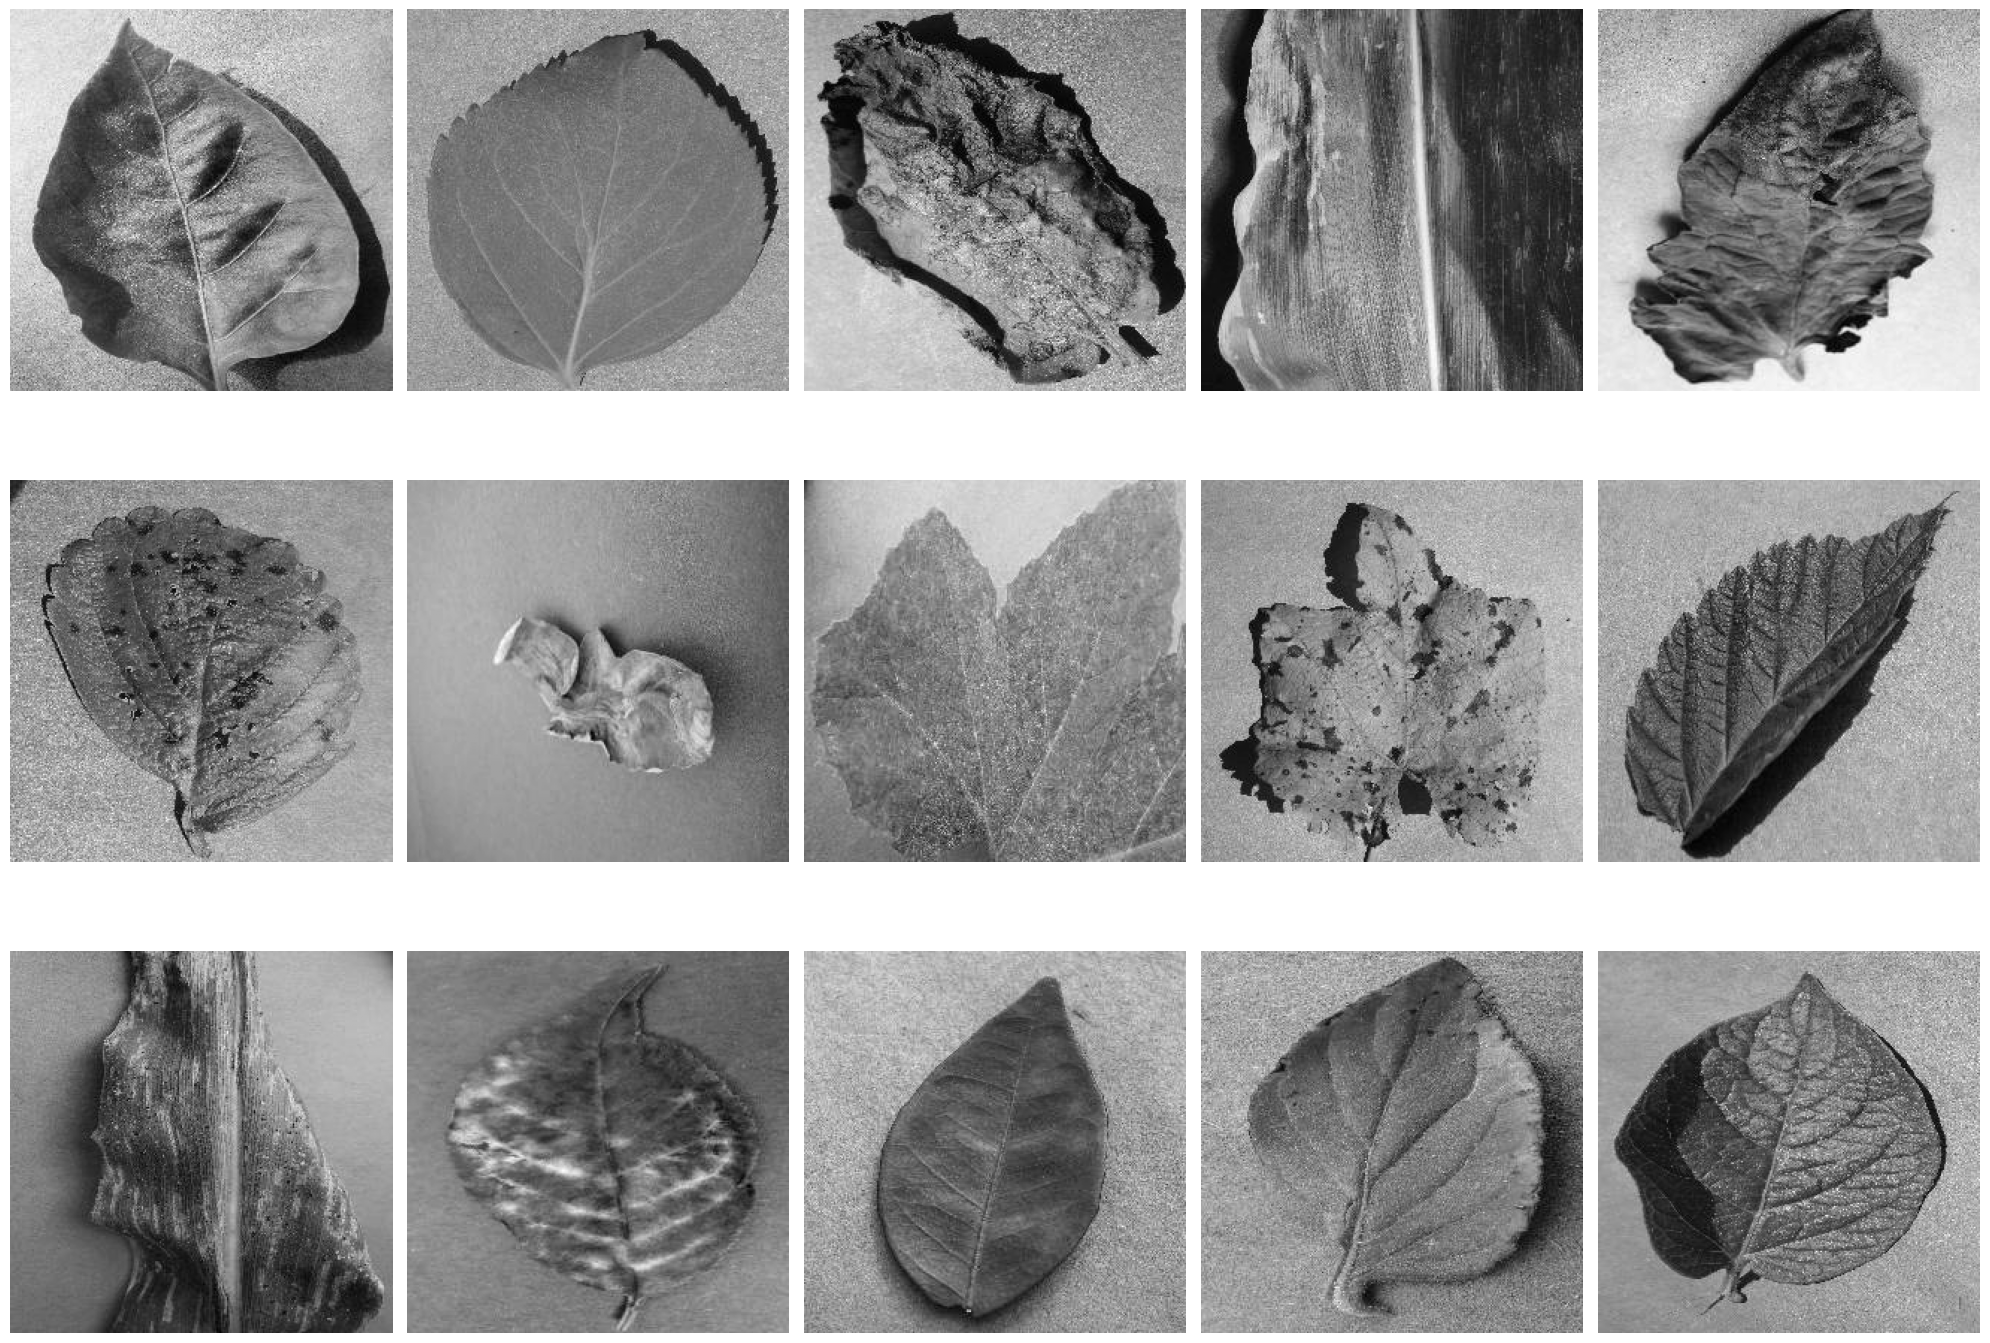

In [46]:
class_names = [
  d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))
]

for class_name in class_names[:10]:
  class_path = os.path.join(dataset_path, class_name)
  num_images = len(os.listdir(class_path))
  print(f"{class_name}: {num_images} images")

fig, axs = plt.subplots(3, 5, figsize=(20, 15))

random_classes = random.sample(class_names, k=3*5)

for i, ax in enumerate(axs.flatten()):
  class_name = random_classes[i]
  class_path = os.path.join(dataset_path, class_name)
  images_in_class = os.listdir(class_path)
  
  random_image_name = random.choice(images_in_class)
  img_path = os.path.join(class_path, random_image_name)
  
  img = Image.open(img_path).convert('L')
  ax.imshow(img, cmap='gray')
  ax.axis('off')
  ax.set(xlabel=class_name, xticks=[], yticks=[])

fig.tight_layout()